In [16]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import swifter
from data_analysis_utils import weighted_permutation_entropy, wpe_row

In [17]:
ecg_test = pd.read_parquet('../data/data_storage/ecg_parquets/test_ecg.parquet')
ecg_train = pd.read_parquet('../data/data_storage/ecg_parquets/train_ecg.parquet')
ecg_val = pd.read_parquet('../data/data_storage/ecg_parquets/val_ecg.parquet')

ecg_df = pd.concat([ecg_test, ecg_train, ecg_val], axis=0).reset_index(drop=True)

harmonic_test= pd.read_parquet('../data/data_storage/harmonic_ou_parquets/test_harmonic.parquet')
harmonic_train = pd.read_parquet('../data/data_storage/harmonic_ou_parquets/train_harmonic.parquet')
harmonic_val = pd.read_parquet('../data/data_storage/harmonic_ou_parquets/val_harmonic.parquet')

harmonic_df = pd.concat([harmonic_test, harmonic_train, harmonic_val], axis=0).reset_index(drop=True)

ou_test= pd.read_parquet('../data/data_storage/harmonic_ou_parquets/test_ou.parquet')
ou_train = pd.read_parquet('../data/data_storage/harmonic_ou_parquets/train_ou.parquet')
ou_val = pd.read_parquet('../data/data_storage/harmonic_ou_parquets/val_ou.parquet')

ou_df = pd.concat([ou_test, ou_train, ou_val], axis=0).reset_index(drop=True)

sp500_test= pd.read_parquet('../data/data_storage/sp500_parquets/test_sp500.parquet')
sp500_train = pd.read_parquet('../data/data_storage/sp500_parquets/train_sp500.parquet')
sp500_val = pd.read_parquet('../data/data_storage/sp500_parquets/val_sp500.parquet')

sp500_df = pd.concat([sp500_test, sp500_train, sp500_val], axis=0).reset_index(drop=True)

We show some examples on how to compute the weighted permutation entropy on a time series.

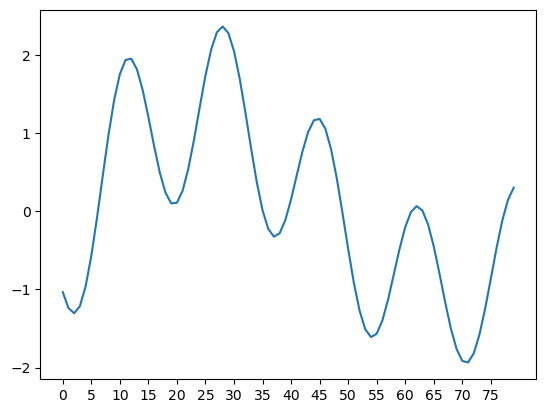

In [22]:
data = harmonic_df.loc[10]
plt.plot(data)
plt.xticks(np.arange(0, len(data), 5))
plt.show()

In [19]:
weighted_permutation_entropy(harmonic_df.loc[10])

0.40323191443425366

We will now compute the weighted permutation entropy of the whole datasets, to compare the data complexity among the different datasets.

In [20]:
harmonic_df.head(10).swifter.apply(wpe_row, axis=1)

Pandas Apply:   0%|          | 0/10 [00:00<?, ?it/s]

0    0.387318
1    0.484376
2    0.404072
3    0.396202
4    0.393128
5    0.400145
6    0.388641
7    0.414217
8    0.809747
9    0.322907
dtype: float64

In [ ]:
ecg_wpe_series = ecg_df.swifter.apply(wpe_row, axis=1)
harmonic_wpe_series = harmonic_df.swifter.apply(wpe_row, axis=1)
ou_wpe_series = ou_df.swifter.apply(wpe_row, axis=1)
sp500_wpe_series = sp500_df.swifter.apply(wpe_row, axis=1)

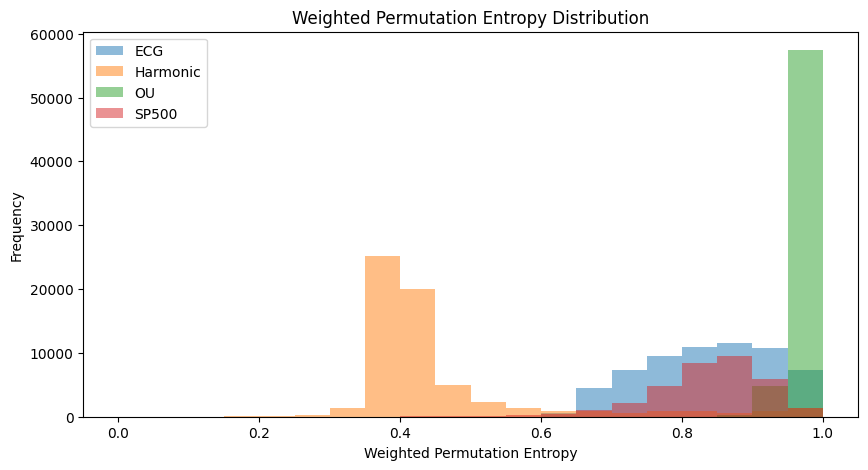

In [ ]:
plt.figure(figsize=(10, 5))
bins = np.arange(0, 1.02, 0.05)  

plt.hist(ecg_wpe_series, bins=bins, alpha=0.5, label='ECG')
plt.hist(harmonic_wpe_series, bins=bins, alpha=0.5, label='Harmonic')
plt.hist(ou_wpe_series, bins=bins, alpha=0.5, label='OU')
plt.hist(sp500_wpe_series, bins=bins, alpha=0.5, label='SP500')

plt.title('Weighted Permutation Entropy Distribution')
plt.xlabel('Weighted Permutation Entropy')
plt.ylabel('Frequency')
plt.legend()
plt.show()

As expected, the completixity of the Harmonic Dataset is the lowest, since the data is more predictable, while the complexity of the OU Dataset, that is completely stochastic, is the highest.. The ECG dataset and the S&P 500 dataset show a similar complexity.

For these reason, we expect the predictive performance of the models to be better on the Harmonic Dataset, while the OU Dataset should be the most difficult one to predict.